## Objective

The objective of this notebook is to identify the best forecasting model for deployment.

Unlike Notebook 01, which evaluates feature engineering under controlled conditions, this notebook focuses solely on maximizing forecasting accuracy through hyperparameter optimization.

Each model is allowed to use the feature version that produces its best performance.

## Imports

In [2]:
import duckdb
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error
)

from pathlib import Path

import joblib
import warnings

import optuna

warnings.filterwarnings("ignore")

/Users/divjyotsinghsuri/Desktop/GridSight/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [3]:
DB_PATH = "../gridsight.duckdb"

TRAIN_END_DATE = "2025-12-31 23:00:00"
TEST_START_DATE = "2026-01-01 00:00:00"
TEST_END_DATE = "2026-06-30 23:00:00"

TARGET = "solar_generation_mw"

RANDOM_STATE = 42

EXPERIMENTS_DIR = Path("../experiments")
MODELS_DIR = Path("../models")

EXPERIMENTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

## Load Gold Dataset

In [4]:
with duckdb.connect(DB_PATH) as con:
    df = con.sql("""
        SELECT *
        FROM gold_training_dataset
        ORDER BY timestamp
    """).df()

CatalogException: Catalog Error: Table with name gold_training_dataset does not exist!
Did you mean "pg_database"?

## Train/Test Split

In [ ]:
train_df = df[df['timestamp'] < TEST_START_DATE]
train_df.head()

,timestamp,solar_generation_mw,temperature_c,relative_humidity_pct,precipitation_mm,cloud_cover_pct,wind_speed_kmh,shortwave_radiation,direct_radiation,diffuse_radiation,...,solar_generation_mw_roll_max_24h,daylight_duration_hours,sunshine_duration_hours,is_daylight,minutes_since_sunrise,daylight_progress_pct,cloud_shortwave_interaction,temperature_shortwave_interaction,wind_temperature_interaction,daylight_progress_shortwave_interaction
0,2023-01-08 00:00:00,2.2075,5.572,81.16,0.040,94.56,19.008,0.0,0.0,0.0,...,9617.9475,8.154408,2.315869,0,0,0.0,0.0,0.0,105.912576,0.0
1,2023-01-08 01:00:00,2.0525,5.336,80.92,0.004,89.76,19.436,0.0,0.0,0.0,...,9617.9475,8.154408,2.315869,0,0,0.0,0.0,0.0,103.710496,0.0
2,2023-01-08 02:00:00,1.9625,5.596,82.72,0.008,93.88,19.540,0.0,0.0,0.0,...,9617.9475,8.154408,2.315869,0,0,0.0,0.0,0.0,109.345840,0.0
3,2023-01-08 03:00:00,2.3225,5.260,83.48,0.084,94.12,19.656,0.0,0.0,0.0,...,9617.9475,8.154408,2.315869,0,0,0.0,0.0,0.0,103.390560,0.0
4,2023-01-08 04:00:00,2.3100,5.216,83.40,0.100,89.72,19.308,0.0,0.0,0.0,...,9617.9475,8.154408,2.315869,0,0,0.0,0.0,0.0,100.710528,0.0


In [ ]:
test_df = df[df['timestamp'] >= TEST_START_DATE]
test_df.head()

,timestamp,solar_generation_mw,temperature_c,relative_humidity_pct,precipitation_mm,cloud_cover_pct,wind_speed_kmh,shortwave_radiation,direct_radiation,diffuse_radiation,...,solar_generation_mw_roll_max_24h,daylight_duration_hours,sunshine_duration_hours,is_daylight,minutes_since_sunrise,daylight_progress_pct,cloud_shortwave_interaction,temperature_shortwave_interaction,wind_temperature_interaction,daylight_progress_shortwave_interaction
26136,2026-01-01 00:00:00,15.137830,-0.568,87.12,0.048,83.36,17.780,0.0,0.0,0.0,...,9107.519598,7.989436,0.0,0,0,0.0,0.0,-0.0,-10.099040,0.0
26137,2026-01-01 01:00:00,15.056636,-0.504,86.52,0.036,84.36,18.340,0.0,0.0,0.0,...,9107.519598,7.989436,0.0,0,0,0.0,0.0,-0.0,-9.243360,0.0
26138,2026-01-01 02:00:00,16.133698,-0.584,86.04,0.076,79.88,18.592,0.0,0.0,0.0,...,9107.519598,7.989436,0.0,0,0,0.0,0.0,-0.0,-10.857728,0.0
26139,2026-01-01 03:00:00,12.625848,-0.556,86.32,0.088,83.28,20.048,0.0,0.0,0.0,...,9107.519598,7.989436,0.0,0,0,0.0,0.0,-0.0,-11.146688,0.0
26140,2026-01-01 04:00:00,12.553904,-0.576,85.76,0.024,82.20,20.524,0.0,0.0,0.0,...,9107.519598,7.989436,0.0,0,0,0.0,0.0,-0.0,-11.821824,0.0


## Features

### v0 Features

In [ ]:
v0_features = [
    "solar_generation_mw_lag_1h",
    "solar_generation_mw_lag_24h",
    "solar_generation_mw_lag_168h"
]

### v1 Features

In [ ]:
v1_features = v0_features + [
    "temperature_c",
    "relative_humidity_pct",
    "precipitation_mm",
    "cloud_cover_pct",
    "wind_speed_kmh",
    
    "shortwave_radiation",
    "direct_radiation",
    "diffuse_radiation",
    "direct_normal_irradiance"
]

### v2 Features

In [ ]:
v2_features = v1_features + [
  "hour",
  "month",
  "day_of_week",
  "day_of_year",
  "is_weekend",
  "year"
]

### v3 Features

In [ ]:
v3_features = v2_features + [
  "daylight_duration_hours",
  "sunshine_duration_hours",
  "is_daylight",
  "minutes_since_sunrise",
  "daylight_progress_pct",
]

### v4 Features

In [ ]:
v4_features = v3_features + [
  "solar_generation_mw_roll_mean_3h",
  "solar_generation_mw_roll_mean_6h",
  "solar_generation_mw_roll_mean_24h",
  
  "solar_generation_mw_roll_std_3h",
  "solar_generation_mw_roll_std_6h",
  "solar_generation_mw_roll_std_24h",
  
  "solar_generation_mw_roll_min_3h",
  "solar_generation_mw_roll_min_6h",
  "solar_generation_mw_roll_min_24h",
  
  "solar_generation_mw_roll_max_3h",
  "solar_generation_mw_roll_max_6h",
  "solar_generation_mw_roll_max_24h"
]

### v5 Features

In [ ]:
v5_features = v4_features + [
  "cloud_shortwave_interaction",
  "temperature_shortwave_interaction",
  "wind_temperature_interaction",
  "daylight_progress_shortwave_interaction"
]

In [ ]:
feature_versions = {
  "V0": v0_features,
  "V1": v1_features,
  "V2": v2_features,
  "V3": v3_features,
  "V4": v4_features,
  "V5": v5_features
}

## Baseline Features

## Baseline Model Performance

Baseline experiments were conducted using default model hyperparameters to evaluate the impact of incremental feature engineering across feature versions (V0–V5). These results establish a reference point before hyperparameter optimization.

| Model | Best Feature Version | Baseline WAPE (%) | Notes |
|------|----------------------|------------------:|-------|
| Linear Regression | V5 | **8.31** | Best overall baseline model |
| XGBoost | V2 | **24.43** | Best baseline among feature versions |
| LightGBM | V2 | **24.98** | Best baseline among feature versions |

Hyperparameter optimization is performed in the following sections to determine whether tuning can further improve forecasting performance beyond these baseline results.

## XGBoost Hyperparameter Optimization

The objective of this section is to identify the optimal combination of feature version and hyperparameters for XGBoost.

Unlike the controlled experiments in Notebook 01, this optimization prioritizes forecasting accuracy. Each feature version (V0–V5) is independently optimized using Optuna, allowing both the feature representation and hyperparameters to vary. The feature version achieving the lowest WAPE is selected as the production configuration for XGBoost.

### Training Data

In [ ]:
xgb_optimization_results = []

for version, features in feature_versions.items():

    X_train = train_df[features]
    y_train = train_df[TARGET]

    X_test = test_df[features]
    y_test = test_df[TARGET]
    
    # OBJECTIVE FUNCTION
    
    def objective(trial):

        learning_rate = trial.suggest_float(
            "learning_rate",
            0.01,
            0.3
        )

        max_depth = trial.suggest_int(
            "max_depth",
            2,
            8
        )
        
        n_estimators = trial.suggest_int(
            "n_estimators",
            100,
            1000
        )
        
        subsample = trial.suggest_float(
            "subsample",
            0.6,
            1.0
        )
        
        colsample_bytree = trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        )
        
        
        model = XGBRegressor(
        learning_rate=learning_rate,
        max_depth=max_depth,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        verbosity=0
    )
        
        model.fit(X_train, y_train)
        
        predictions = model.predict(X_test)
        
        wape = (abs(y_test - predictions).sum() / y_test.sum()) * 100
        
        return wape
    
    
    study = optuna.create_study(
    direction="minimize"
)

    study.optimize(
    objective,
    n_trials=150
)
    
    xgb_optimization_results.append({
        "Version": version,
        "Best WAPE": study.best_value,
        "Best Params": study.best_params
    })
    
        


In [ ]:
results_df = pd.DataFrame(xgb_optimization_results)
results_df = results_df.sort_values("Best WAPE")
results_df

,Version,Best WAPE,Best Params
3,V3,10.477030,"{'learning_rate': 0.2836535638476923, 'max_dep..."
2,V2,10.939404,"{'learning_rate': 0.28831674281824593, 'max_de..."
4,V4,12.863604,"{'learning_rate': 0.27900020095485417, 'max_de..."
5,V5,15.731079,"{'learning_rate': 0.18412594484677056, 'max_de..."
1,V1,19.905930,"{'learning_rate': 0.24125419053249358, 'max_de..."
0,V0,28.744847,"{'learning_rate': 0.1844995451834629, 'max_dep..."


### Best Parameters

In [ ]:
best_result = results_df.iloc[0]

best_version = best_result["Version"]
best_wape = best_result["Best WAPE"]
best_params = best_result["Best Params"]

In [ ]:
print(best_version)
print(best_wape)
print(best_params)

V3
10.477030148162667
{'learning_rate': 0.2836535638476923, 'max_depth': 3, 'n_estimators': 955, 'subsample': 0.99907535930191, 'colsample_bytree': 0.8889593670524224}


### Final Model Train

In [ ]:
best_features = feature_versions[best_version]

X_train = train_df[best_features]
y_train = train_df[TARGET]

X_test = test_df[best_features]
y_test = test_df[TARGET]

final_model = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    verbosity=0
)

final_model.fit(X_train, y_train)

predictions = final_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
wape = (abs(y_test - predictions).sum() / y_test.sum()) * 100

In [ ]:
print(f"Best Feature Version: {best_version}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"WAPE: {wape:.2f}%")

Best Feature Version: V3
MAE: 1171.96
RMSE: 2180.44
WAPE: 10.48%


### Save Model

In [ ]:
joblib.dump(final_model, "models/xgboost_v3_optuna.joblib")

['models/xgboost_v3_optuna.joblib']

### Prediction Plot

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

comparison.head(20)

,Actual,Predicted
26136,15.137830,0.000000
26137,15.056636,0.000000
26138,16.133698,0.000000
26139,12.625848,0.000000
26140,12.553904,0.000000
26141,12.576750,0.000000
26142,16.808553,59.618736
26143,454.760703,431.052643
26144,3061.433624,2270.049561
26145,5952.409014,5972.915527


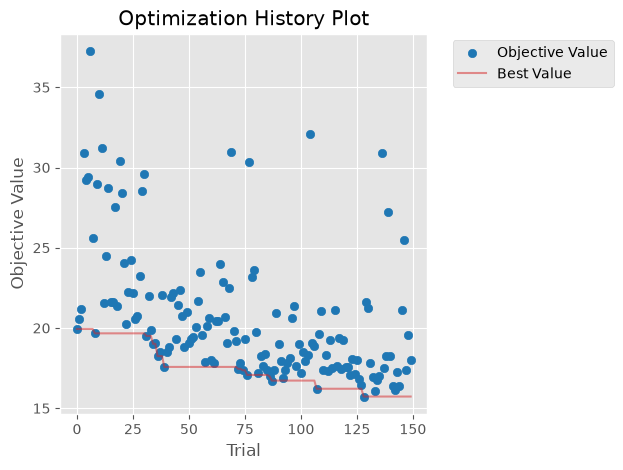

In [ ]:
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.show()

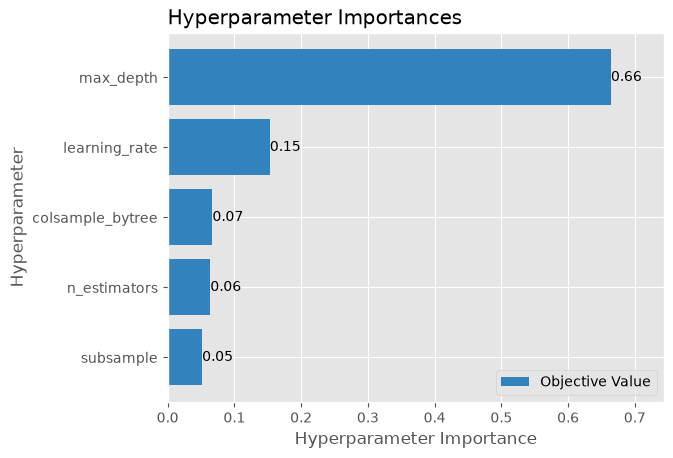

In [ ]:
optuna.visualization.matplotlib.plot_param_importances(study)
plt.show()

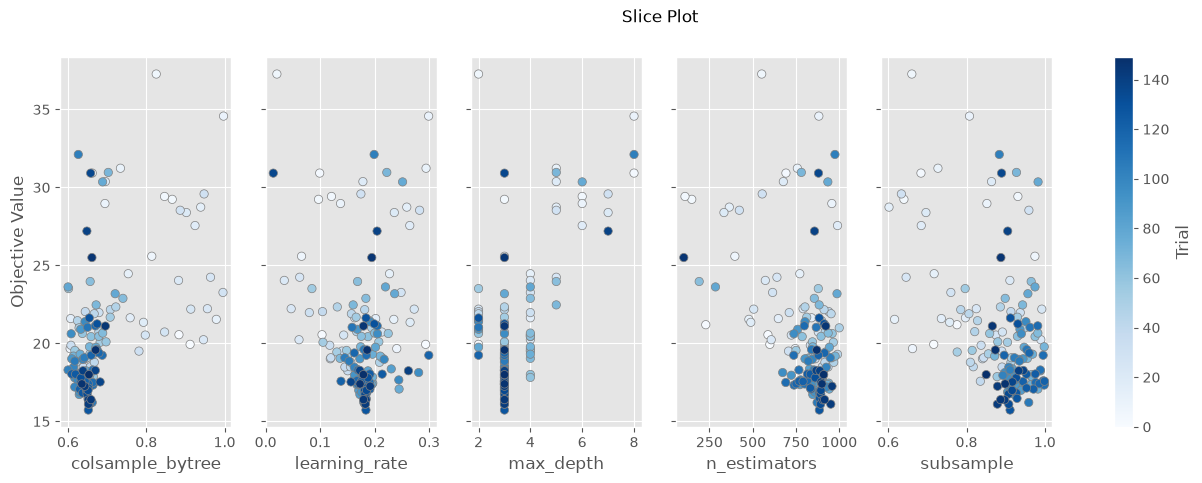

In [ ]:
optuna.visualization.matplotlib.plot_slice(study)
plt.show()

### XGBoost Optimization Summary

| Parameter | Value |
|-----------|-------|
| Optimization Library | Optuna |
| Optimization Trials | 150 |
| Objective Metric | WAPE |
| Best Feature Version | **V3** |
| Best WAPE | **10.48%** |
| Best Hyperparameter | **Maximum Tree Depth (`max_depth`)** |

### Best Hyperparameters

| Hyperparameter | Optimal Value |
|---------------|--------------:|
| Learning Rate | 0.2837 |
| Maximum Depth | 3 |
| Number of Trees | 955 |
| Subsample | 0.9991 |
| Column Sample by Tree | 0.8890 |

## LightGBM Hyperparameter Optimization

### Training Model

In [ ]:
LightGBM_optimization_results = []

for version, features in feature_versions.items():

    X_train = train_df[features]
    y_train = train_df[TARGET]

    X_test = test_df[features]
    y_test = test_df[TARGET]
    
    # OBJECTIVE FUNCTION
    
    def objective(trial):

        learning_rate = trial.suggest_float(
            "learning_rate",
            0.01,
            0.3
        )

        num_leaves = trial.suggest_int(
            "num_leaves",
            20,
            100
        )
        
        n_estimators = trial.suggest_int(
            "n_estimators",
            100,
            1000
        )
        
        max_depth = trial.suggest_int(
            "max_depth",
            2,
            8
        )
        
        feature_fraction = trial.suggest_float(
            "feature_fraction",
            0.6,
            1.0
        )
        
        bagging_fraction = trial.suggest_float(
          "bagging_fraction",
          0.6,
          1.0
        )
        
        
        model = LGBMRegressor(
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        max_depth=max_depth,
        n_estimators=n_estimators,
        feature_fraction=feature_fraction,
        bagging_fraction=bagging_fraction,
        objective="regression",
        random_state=RANDOM_STATE,
        verbosity=-1
    )
        
        model.fit(X_train, y_train)
        
        predictions = model.predict(X_test)
        
        wape = (abs(y_test - predictions).sum() / y_test.sum()) * 100
        
        return wape
    
    
    study = optuna.create_study(
    direction="minimize"
)

    study.optimize(
    objective,
    n_trials=150
)
    
    LightGBM_optimization_results.append({
        "Version": version,
        "Best WAPE": study.best_value,
        "Best Params": study.best_params
    })
    
        


### Results

In [ ]:
results_df = pd.DataFrame(LightGBM_optimization_results)
results_df = results_df.sort_values("Best WAPE")
results_df

,Version,Best WAPE,Best Params
3,V3,10.787906,"{'learning_rate': 0.24163012030844397, 'num_le..."
2,V2,11.099032,"{'learning_rate': 0.24323628279150342, 'num_le..."
4,V4,11.415087,"{'learning_rate': 0.2918616118362678, 'num_lea..."
5,V5,14.440794,"{'learning_rate': 0.2927115847998464, 'num_lea..."
1,V1,19.560697,"{'learning_rate': 0.2454517668053591, 'num_lea..."
0,V0,28.625556,"{'learning_rate': 0.2689793365732506, 'num_lea..."


In [ ]:
best_result = results_df.iloc[0]

best_version = best_result["Version"]
best_wape = best_result["Best WAPE"]
best_params = best_result["Best Params"]

In [ ]:
print(best_version)
print(best_wape)
print(best_params)

V3
10.78790565764738
{'learning_rate': 0.24163012030844397, 'num_leaves': 64, 'n_estimators': 758, 'max_depth': 3, 'feature_fraction': 0.977167652017044, 'bagging_fraction': 0.7532431125742236}


### Final Model Training

In [ ]:
best_features = feature_versions[best_version]

X_train = train_df[best_features]
y_train = train_df[TARGET]

X_test = test_df[best_features]
y_test = test_df[TARGET]

final_model = LGBMRegressor(
    **best_params,
    objective="regression",  
    random_state=RANDOM_STATE,
    verbosity=0
)

final_model.fit(X_train, y_train)

predictions = final_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
wape = (abs(y_test - predictions).sum() / y_test.sum()) * 100

In [ ]:
print(f"Best Feature Version: {best_version}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"WAPE: {wape:.2f}%")

Best Feature Version: V3
MAE: 1206.74
RMSE: 2231.61
WAPE: 10.79%


### Saving Model

In [ ]:
joblib.dump(final_model, "models/lightgbm_v3_optuna.joblib")

['models/lightgbm_v3_optuna.joblib']

### Prediction Plot

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

comparison.head(20)

,Actual,Predicted
26136,15.137830,-12.394271
26137,15.056636,-10.130329
26138,16.133698,-5.769142
26139,12.625848,-8.848370
26140,12.553904,-30.417830
26141,12.576750,29.074513
26142,16.808553,82.462810
26143,454.760703,496.410572
26144,3061.433624,2208.223012
26145,5952.409014,5976.108643


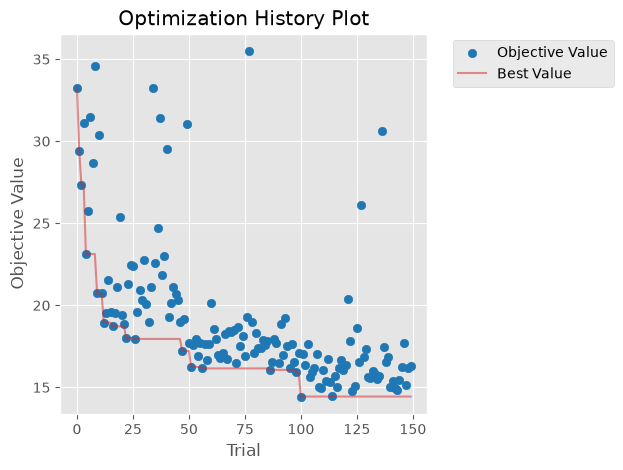

In [ ]:
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.show()

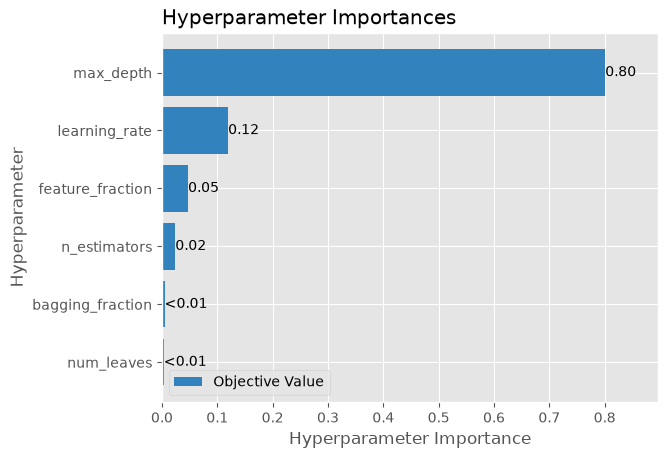

In [ ]:
optuna.visualization.matplotlib.plot_param_importances(study)
plt.show()

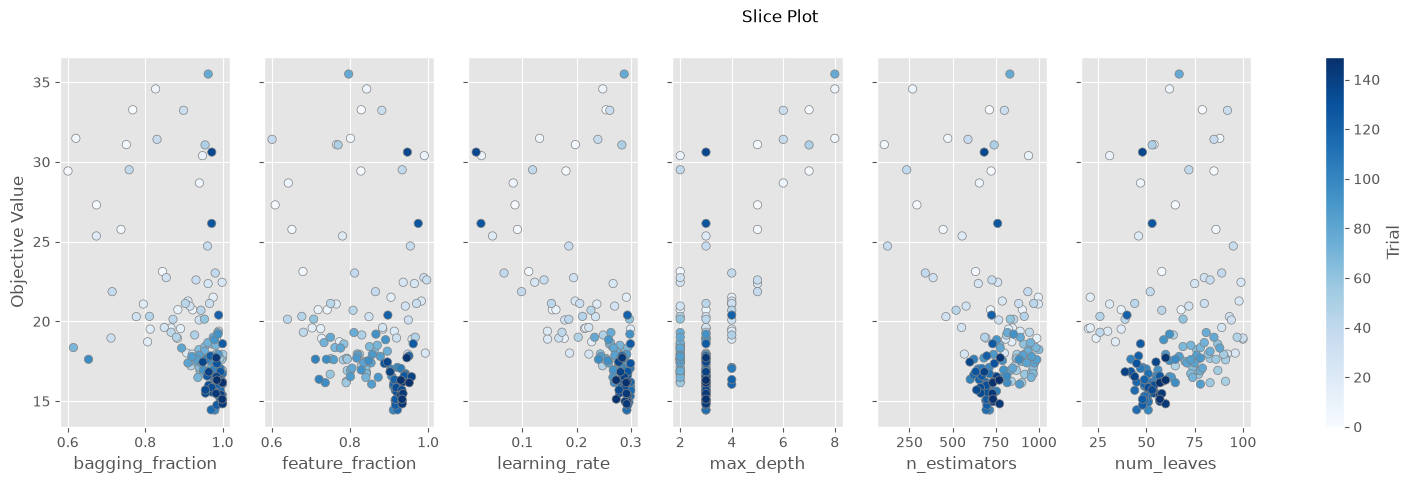

In [ ]:
optuna.visualization.matplotlib.plot_slice(study)
plt.show()

### LightGBM Optimization Summary

| Metric | Value |
|--------|-------|
| Optimization Method | Optuna |
| Trials | 150 |
| Best Feature Version | **V3** |
| Best WAPE | **10.79%** |
| Best Hyperparameter | **Maximum Tree Depth (`max_depth`)** |

### Best Hyperparameters

| Hyperparameter | Optimal Value |
|---------------|--------------:|
| Learning Rate | 0.2416 |
| Number of Leaves | 64 |
| Maximum Depth | 3 |
| Number of Estimators | 758 |
| Feature Fraction | 0.9772 |
| Bagging Fraction | 0.7532 |

## Ridge Regression Optimization

Ordinary Least Squares Linear Regression achieved the best baseline performance in Notebook 01. To investigate whether regularization could further improve generalization, Ridge Regression was optimized using Optuna.

The regularization strength (`alpha`) was tuned independently across each feature version (V0–V5), with WAPE used as the optimization objective.

In [ ]:
ridge_results = []

for version, features in feature_versions.items():

    X_train = train_df[features]
    y_train = train_df[TARGET]

    X_test = test_df[features]
    y_test = test_df[TARGET]

    def objective(trial):

        alpha = trial.suggest_float(
            "alpha",
            1e-4,
            100,
            log=True
        )

        model = Ridge(alpha=alpha)

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        predictions = np.clip(predictions, 0, None)

        wape = (abs(y_test - predictions).sum() / y_test.sum()) * 100

        return wape

    study = optuna.create_study(direction="minimize")

    study.optimize(
        objective,
        n_trials=100,
        show_progress_bar=False
    )

    ridge_results.append({
        "Version": version,
        "Best WAPE": study.best_value,
        "Best Alpha": study.best_params["alpha"]
    })

results_df = pd.DataFrame(ridge_results)
results_df = results_df.sort_values("Best WAPE")

display(results_df)

best_result = results_df.iloc[0]

best_version = best_result["Version"]
best_alpha = best_result["Best Alpha"]

print(f"\nBest Feature Version : {best_version}")
print(f"Best Alpha           : {best_alpha:.6f}")
print(f"Best WAPE            : {best_result['Best WAPE']:.4f}%")

### Final Model Training

In [ ]:
best_features = feature_versions["V5"]

X_train = train_df[best_features]
y_train = train_df[TARGET]

X_test = test_df[best_features]
y_test = test_df[TARGET]

ridge_model = Ridge(alpha=99.819268)

ridge_model.fit(X_train, y_train)

predictions = ridge_model.predict(X_test)

predictions = np.clip(predictions, 0, None)

In [ ]:
mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
wape = (abs(y_test - predictions).sum() / y_test.sum()) * 100

### Results

In [ ]:
print(f"Best Feature Version: {best_version}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"WAPE: {wape:.2f}%")

Best Feature Version: V5
MAE: 871.80
RMSE: 1302.33
WAPE: 7.79%


### Saving Model

In [ ]:
joblib.dump(
    ridge_model,
    "models/ridge_v5_optuna.joblib"
)

['models/ridge_v5_optuna.joblib']

### Prediction Plots

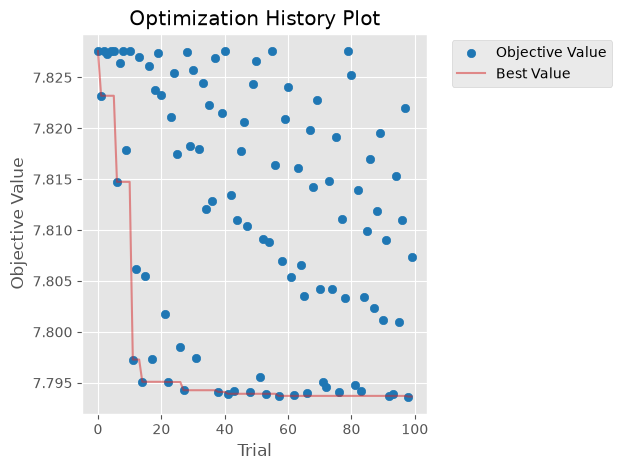

In [ ]:
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.show()

### Ridge Regression Optimization Summary

| Metric | Value |
|--------|-------|
| Optimization Method | Optuna |
| Trials | 100 |
| Best Feature Version | **V5** |
| Best WAPE | **7.79%** |
| Best Hyperparameter | **Regularization Strength (`alpha`)** |

### Best Hyperparameters

| Hyperparameter | Optimal Value |
|---------------|--------------:|
| Alpha | 99.8193 |

## Production Model Comparison

The optimized models were compared to identify the most suitable forecasting pipeline for deployment. Each model was evaluated using its best-performing feature version and optimal hyperparameters obtained through Optuna.

## Final Production Model

Among all optimized forecasting models, Ridge Regression achieved the lowest forecasting error with a WAPE of **7.79%** using Feature Version **V5**.

This model is selected as the production forecasting model for GridSight due to its superior predictive performance and computational efficiency.

In [ ]:
print("Selected Model :", "Ridge Regression")
print("Feature Version :", "V5")
print("WAPE :", "7.79%")
print("Alpha :", 99.819268)

Selected Model : Ridge Regression
Feature Version : V5
WAPE : 7.79%
Alpha : 99.819268


## Save Production Model

The selected production model is serialized using Joblib for deployment within the GridSight forecasting pipeline.

In [ ]:
joblib.dump(
    ridge_model,
    "models/production_model.joblib"
)

['models/production_model.joblib']

## Conclusion

Hyperparameter optimization substantially improved the forecasting performance of all evaluated machine learning models.

Gradient boosting models benefited significantly from tuning, with XGBoost reducing WAPE from **24.43%** to **10.48%** and LightGBM reducing WAPE from **24.99%** to **10.79%**.

Among the tree-based models, both XGBoost and LightGBM independently selected **Feature Version V3**, suggesting that daylight-related features provided the most informative representation for gradient boosting methods.

Linear models exhibited different behavior. Ridge Regression achieved its best performance using **Feature Version V5**, indicating that interaction features and additional engineered variables were particularly beneficial for linear modeling.

Overall, Ridge Regression produced the lowest forecasting error (**7.79% WAPE**) and was selected as the production forecasting model for the GridSight platform.

## Production Model Comparison

| Rank | Model | Baseline WAPE | Tuned WAPE | Best Feature Version |
|:---:|------------------|-------------:|-----------:|:--------------------:|
| 🥇 | **Ridge Regression** | 8.31% | **7.79%** | **V5** |
| 🥈 | **XGBoost** | 24.43% | 10.48% | V3 |
| 🥉 | **LightGBM** | 24.99% | 10.79% | V3 |